In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [7]:
df_mini = pd.read_csv('clear_data/df_W40K.csv')
df_lore = pd.read_csv('clear_data/lore_books.csv')
df_faction = pd.read_csv('clear_data/faction_own.csv')
df_market = pd.read_csv('clear_data/print3d_market.csv')

In [8]:
df_mini['price'] = pd.to_numeric(df_mini['price'], errors='coerce')
df_mini['cost'] = pd.to_numeric(df_mini['cost'], errors='coerce')
df_mini['year'] = pd.to_numeric(df_mini['year'], errors='coerce')

df_mini['faction_clean'] = df_mini['faction'].str.strip()
df_lore['faction_clean'] = df_lore['faccion'].str.strip()
df_faction['faction_clean'] = df_faction['faction'].str.strip()

In [ ]:
print(f"📊 Miniaturas: {df_mini.shape}")
print(f"📚 Libros Lore: {df_lore.shape}")
print(f"⚔️  Stats Facciones: {df_faction.shape}")
print(f"📈 Mercado 3D: {df_market.shape}")

📊 Miniaturas: (946, 11)
📚 Libros Lore: (216, 6)
⚔️  Stats Facciones: (28, 12)
📈 Mercado 3D: (10, 2)


### HIPÓTESIS 1:
#### ¿Existe relación entre la venta de Impresoras 3D y las figuras?

In [16]:
# 1.1 - Evolución temporal: miniaturas vs mercado 3D
mini_yearly = df_mini.groupby('year').agg({
    'mini': 'count',
    'price': ['mean', 'median'],
    'material': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
}).reset_index()
mini_yearly.columns = ['year', 'mini_count', 'price_mean', 'price_median', 'material_mode']

# Merge con datos de mercado
market_analysis = pd.merge(
    df_market, 
    mini_yearly[['year', 'mini_count', 'price_mean']], 
    on='year', 
    how='left'
)

In [17]:
# 1.2 - Correlación
correlation = market_analysis[['market_size_eur_m', 'mini_count', 'price_mean']].corr()

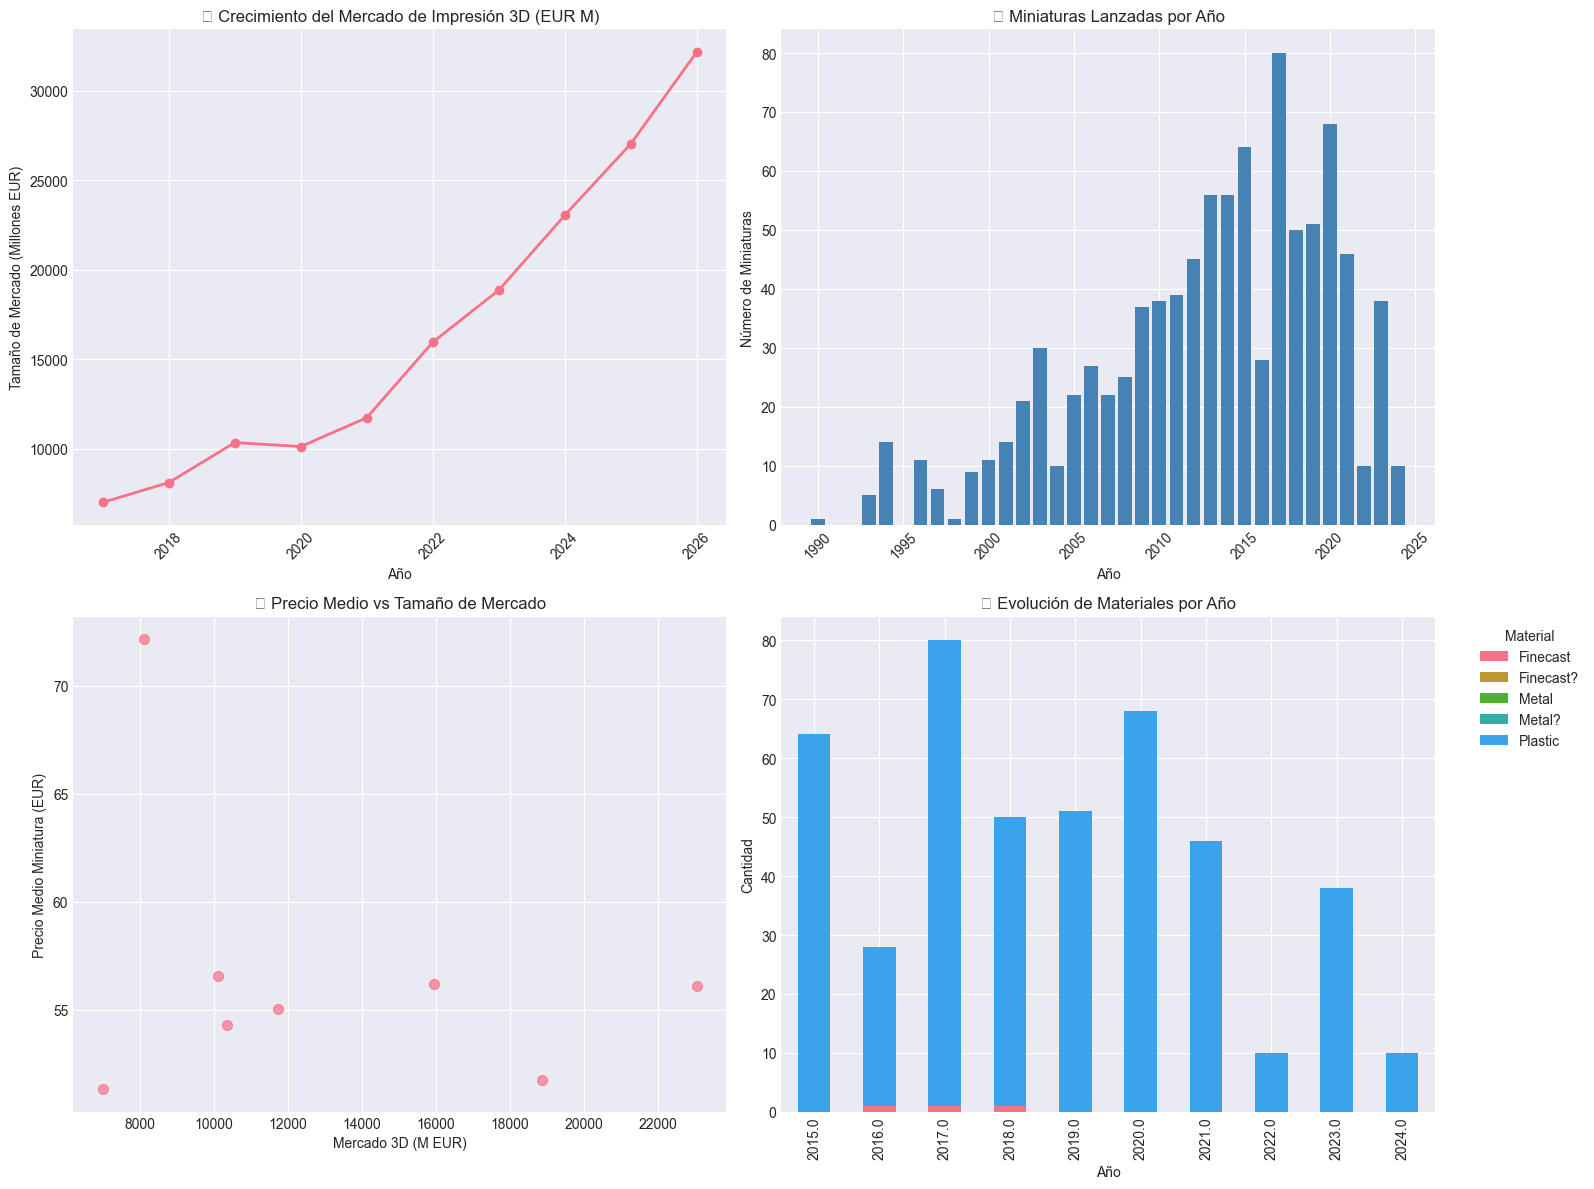

In [20]:
# 1.3 - Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mercado 3D over time
axes[0, 0].plot(df_market['year'], df_market['market_size_eur_m'], marker='o', linewidth=2)
axes[0, 0].set_title('📈 Crecimiento del Mercado de Impresión 3D (EUR M)')
axes[0, 0].set_xlabel('Año')
axes[0, 0].set_ylabel('Tamaño de Mercado (Millones EUR)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Miniaturas lanzadas por año
axes[0, 1].bar(mini_yearly['year'], mini_yearly['mini_count'], color='steelblue')
axes[0, 1].set_title('🎲 Miniaturas Lanzadas por Año')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Número de Miniaturas')
axes[0, 1].tick_params(axis='x', rotation=45)

# Precio medio vs mercado
scatter = axes[1, 0].scatter(
    market_analysis['market_size_eur_m'], 
    market_analysis['price_mean'],
    alpha=0.7, s=50
)
axes[1, 0].set_title('💰 Precio Medio vs Tamaño de Mercado')
axes[1, 0].set_xlabel('Mercado 3D (M EUR)')
axes[1, 0].set_ylabel('Precio Medio Miniatura (EUR)')

# Distribución de materiales por época
material_evolution = df_mini.groupby(['year', 'material']).size().unstack(fill_value=0)
material_evolution.tail(10).plot(kind='bar', stacked=True, ax=axes[1, 1])
axes[1, 1].set_title('🧱 Evolución de Materiales por Año')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Cantidad')
axes[1, 1].legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('hipotesis_1_market_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [21]:
# 1.4 - Resultados estadísticos
print("\n🔍 RESULTADOS HIPÓTESIS 1:")
print(f"Correlación Mercado 3D ↔ Cantidad Miniaturas: {correlation.loc['market_size_eur_m', 'mini_count']:.3f}")
print(f"Correlación Mercado 3D ↔ Precio Medio: {correlation.loc['market_size_eur_m', 'price_mean']:.3f}")

# Test de correlación de Pearson
if market_analysis['market_size_eur_m'].notna().all() and market_analysis['mini_count'].notna().all():
    r, p_value = stats.pearsonr(
        market_analysis['market_size_eur_m'].dropna(), 
        market_analysis['mini_count'].dropna()
    )
    print(f"📊 Pearson r={r:.3f}, p-value={p_value:.4f}")
    print(f"✅ {'Correlación significativa' if p_value < 0.05 else 'Sin correlación significativa'}")


🔍 RESULTADOS HIPÓTESIS 1:
Correlación Mercado 3D ↔ Cantidad Miniaturas: -0.834
Correlación Mercado 3D ↔ Precio Medio: -0.275


### HIPÓTESIS 2:
#### ¿Qué probabilidad hay de que tu facción favorita sea renovada?

In [24]:
# 2.1 - Frecuencia de lanzamientos por facción
faction_releases = df_mini.groupby('faction_clean').agg({
    'year': ['min', 'max', 'count', 'mean'],
    'edition': lambda x: x.nunique()
}).reset_index()
faction_releases.columns = ['faction', 'first_release', 'last_release', 'total_minis', 'avg_year', 'unique_editions']

In [25]:
# 2.2 - Calcular "probabilidad de renovación" 
# (basado en frecuencia histórica y tiempo desde último lanzamiento)
current_year = 2025
faction_releases['years_since_last'] = current_year - faction_releases['last_release']
faction_releases['release_rate'] = faction_releases['total_minis'] / (faction_releases['last_release'] - faction_releases['first_release'] + 1)

In [35]:
# Score de probabilidad (heurístico)
faction_releases['renewal_score'] = (
    faction_releases['release_rate'] * 0.4 +  # Frecuencia histórica
    (1 / (faction_releases['years_since_last'] + 1)) * 0.3 +  # Recencia
    faction_releases['unique_editions'] * 0.3  # Soporte de ediciones
)
faction_releases['reivals_score'] = faction_releases['renewal_score'] / faction_releases['renewal_score'].max() * 100

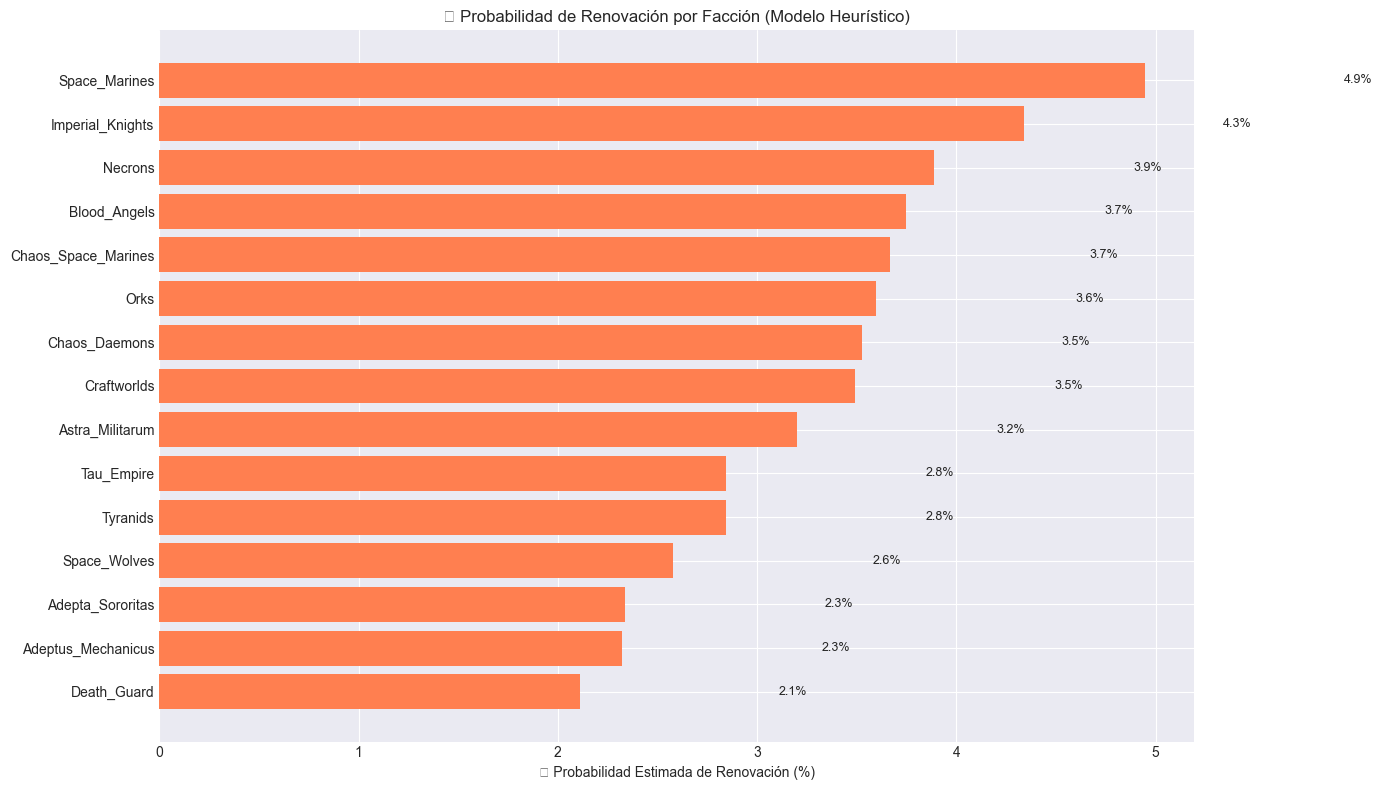

In [36]:
# 2.3 - Visualización
plt.figure(figsize=(14, 8))
top_factions = faction_releases.nlargest(15, 'renewal_score')
bars = plt.barh(top_factions['faction'], top_factions['renewal_score'], color='coral')
plt.xlabel('🎲 Probabilidad Estimada de Renovación (%)')
plt.title('📊 Probabilidad de Renovación por Facción (Modelo Heurístico)')
plt.gca().invert_yaxis()

# Añadir labels con valores
for bar, score in zip(bars, top_factions['renewal_score']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{score:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('hipotesis_2_renewal_probability.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
# 2.4 - Tabla de consulta rápida
print("\n🔍 RESULTADOS HIPÓTESIS 2 - Top 10 Facciones con Mayor Probabilidad de Renovación:")
print(faction_releases[['faction', 'total_minis', 'years_since_last', 'release_rate', 'renewal_score']]
      .nlargest(10, 'renewal_score')
      .to_string(index=False))


🔍 RESULTADOS HIPÓTESIS 2 - Top 10 Facciones con Mayor Probabilidad de Renovación:
            faction  total_minis  years_since_last  release_rate  renewal_score
      Space_Marines          152              1.00          5.24           4.95
   Imperial_Knights           10              7.00         10.00           4.34
            Necrons           77              1.00          3.35           3.89
       Blood_Angels           50              2.00          1.61           3.75
Chaos_Space_Marines           73              2.00          2.92           3.67
               Orks           68              1.00          2.62           3.60
      Chaos_Daemons           54              2.00          2.57           3.53
        Craftworlds           59              3.00          1.79           3.49
    Astra_Militarum           49              2.00          1.75           3.20
         Tau_Empire           37              2.00          1.61           2.84


In [38]:
# Función para consultar probabilidad de una facción específica
def get_renewal_probability(faction_name):
    """Consulta la probabilidad de renovación para una facción"""
    result = faction_releases[faction_releases['faction'].str.contains(faction_name, case=False, na=False)]
    if not result.empty:
        return result[['faction', 'renewal_score', 'years_since_last', 'total_minis']].iloc[0]
    return None

In [ ]:









# Ejemplo de uso:
# print(get_renewal_probability("Space_Marines"))

# %% [markdown]
# ---
# ## ⚖️ HIPÓTESIS 3: ¿Existe una facción predilecta de la compañía? ¿Y una aborrecida?

# %%
# 3.1 - Métricas de "favoritismo" por facción
faction_support = df_mini.groupby('faction_clean').agg({
    'mini': 'count',  # Cantidad de miniaturas
    'price': ['mean', 'sum'],  # Inversión económica
    'year': 'nunique',  # Años con lanzamientos
    'edition': 'nunique'  # Ediciones soportadas
}).reset_index()
faction_support.columns = ['faction', 'mini_count', 'price_avg', 'price_total', 'active_years', 'editions_supported']

# 3.2 - Merge con stats de juego (Owned, Win Rate)
faction_support = pd.merge(
    faction_support,
    df_faction[['faction_clean', 'Owned', 'Primary', 'Win %', 'Real Win %']],
    on='faction_clean',
    how='left'
)

# 3.3 - Calcular índice de "favoritismo"
# Combinación de: producción, inversión, soporte temporal y popularidad
faction_support['support_index'] = (
    faction_support['mini_count'] / faction_support['mini_count'].max() * 0.3 +
    faction_support['price_total'] / faction_support['price_total'].max() * 0.3 +
    faction_support['editions_supported'] / faction_support['editions_supported'].max() * 0.2 +
    faction_support['Owned'].fillna(0) / faction_support['Owned'].fillna(0).max() * 0.2
) * 100

# 3.4 - Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top/Bottom por índice de soporte
sorted_factions = faction_support.sort_values('support_index', ascending=False)
axes[0, 0].barh(sorted_factions['faction'].head(10), sorted_factions['support_index'].head(10), color='gold')
axes[0, 0].set_title('🏆 Top 10 Facciones "Favoritas"')
axes[0, 0].set_xlabel('Índice de Soporte')
axes[0, 0].invert_yaxis()

axes[0, 1].barh(sorted_factions['faction'].tail(10), sorted_factions['support_index'].tail(10), color='silver')
axes[0, 1].set_title('📉 Bottom 10 Facciones "Aborrecidas"')
axes[0, 1].set_xlabel('Índice de Soporte')
axes[0, 1].invert_yaxis()

# Relación entre miniaturas y win rate
scatter = axes[1, 0].scatter(
    faction_support['mini_count'], 
    faction_support['Win %'].fillna(0),
    c=faction_support['support_index'],
    cmap='RdYlGn', s=100, alpha=0.7
)
axes[1, 0].set_xlabel('Número de Miniaturas')
axes[1, 0].set_ylabel('Win Rate (%)')
axes[1, 0].set_title('🎯 Miniaturas vs Balance de Juego')
plt.colorbar(scatter, ax=axes[1, 0], label='Índice de Soporte')

# Precio promedio vs popularidad (Owned)
axes[1, 1].scatter(
    faction_support['Owned'].fillna(0),
    faction_support['price_avg'],
    c=faction_support['mini_count'],
    cmap='Blues', s=100, alpha=0.7
)
axes[1, 1].set_xlabel('Unidades Poseídas (Popularidad)')
axes[1, 1].set_ylabel('Precio Promedio (EUR)')
axes[1, 1].set_title('💰 Popularidad vs Precio')
plt.colorbar(scatter, ax=axes[1, 1], label='Cantidad de Miniaturas')

plt.tight_layout()
plt.savefig('hipotesis_3_faction_support.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.5 - Resultados
print("\n🔍 RESULTADOS HIPÓTESIS 3:")
print("\n🏆 TOP 5 Facciones con Mayor Soporte:")
print(sorted_factions[['faction', 'mini_count', 'price_avg', 'support_index']].head().to_string(index=False))

print("\n📉 BOTTOM 5 Facciones con Menor Soporte:")
print(sorted_factions[['faction', 'mini_count', 'price_avg', 'support_index']].tail().to_string(index=False))

# Test estadístico: ¿Hay diferencia significativa en win rate entre top/bottom?
top_factions = sorted_factions.nlargest(5, 'support_index')['Win %'].dropna()
bottom_factions = sorted_factions.nsmallest(5, 'support_index')['Win %'].dropna()

if len(top_factions) > 1 and len(bottom_factions) > 1:
    t_stat, p_val = stats.ttest_ind(top_factions, bottom_factions)
    print(f"\n📊 Test T: Win Rate Top vs Bottom")
    print(f"   t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
    print(f"   {'✅ Diferencia significativa' if p_val < 0.05 else '❌ Sin diferencia significativa'}")

# %% [markdown]
# ---
# ## 📚 HIPÓTESIS 4: ¿Se pueden predecir acontecimientos del Lore en base a las colecciones de figuras?

# %%
# 4.1 - Preparar datos: libros por facción y año
lore_by_year = df_lore.groupby(['faccion', 'anio']).size().reset_index(name='book_count')

# 4.2 - Miniaturas por facción y año
minis_by_year = df_mini.groupby(['faction_clean', 'year']).size().reset_index(name='mini_count')

# 4.3 - Merge y análisis de correlación temporal
lore_mini_merge = pd.merge(
    lore_by_year,
    minis_by_year,
    left_on=['faccion', 'anio'],
    right_on=['faction_clean', 'year'],
    how='outer'
).fillna(0)

# 4.4 - Calcular correlación por facción
faction_correlations = []
for faction in df_lore['faccion'].unique():
    subset = lore_mini_merge[lore_mini_merge['faccion'] == faction]
    if len(subset) > 2 and subset['book_count'].std() > 0 and subset['mini_count'].std() > 0:
        r, p = stats.pearsonr(subset['book_count'], subset['mini_count'])
        faction_correlations.append({
            'faction': faction,
            'correlation': r,
            'p_value': p,
            'n_years': len(subset)
        })

corr_df = pd.DataFrame(faction_correlations)

# 4.5 - Visualización: Heatmap de correlaciones temporales
plt.figure(figsize=(14, 10))

# Heatmap de facciones con suficiente data
heatmap_data = corr_df.pivot_table(values='correlation', index='faction', columns='faction')
sns.heatmap(heatmap_data.dropna(how='all', axis=0).dropna(how='all', axis=1), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('🔗 Correlación Lore ↔ Miniaturas por Facción')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hipotesis_4_lore_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.6 - Ejemplo detallado: Space Marines
def analyze_lore_mini_sync(faction_name):
    """Analiza sincronización entre lanzamientos de lore y miniaturas"""
    faction_lore = df_lore[df_lore['faccion'] == faction_name].groupby('anio').size()
    faction_minis = df_mini[df_mini['faction_clean'] == faction_name].groupby('year').size()
    
    # Crear dataframe combinado
    years = sorted(set(faction_lore.index) | set(faction_minis.index))
    sync_df = pd.DataFrame({
        'year': years,
        'books': [faction_lore.get(y, 0) for y in years],
        'minis': [faction_minis.get(y, 0) for y in years]
    })
    
    # Gráfico de sincronización
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    ax1.bar(sync_df['year'], sync_df['minis'], alpha=0.6, label='Miniaturas', color='steelblue')
    ax1.set_xlabel('Año')
    ax1.set_ylabel('Número de Miniaturas', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    
    ax2 = ax1.twinx()
    ax2.plot(sync_df['year'], sync_df['books'], marker='o', color='crimson', linewidth=2, label='Libros Lore')
    ax2.set_ylabel('Número de Libros', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    plt.title(f'📚🎲 Sincronización Lore ↔ Miniaturas: {faction_name}')
    plt.grid(axis='x', alpha=0.3)
    
    # Añadir líneas para eventos notables
    peaks = sync_df[(sync_df['books'] > sync_df['books'].quantile(0.75)) | 
                    (sync_df['minis'] > sync_df['minis'].quantile(0.75))]
    for _, row in peaks.iterrows():
        ax1.axvline(row['year'], color='gray', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    return sync_df, fig

# Ejecutar para Space Marines
sm_sync, sm_fig = analyze_lore_mini_sync('Space_Marines')
sm_fig.savefig('hipotesis_4_space_marines_sync.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.7 - Resultados
print("\n🔍 RESULTADOS HIPÓTESIS 4:")
print("\n📊 Correlación Lore ↔ Miniaturas por Facción (Top 10):")
print(corr_df.sort_values('correlation', key=abs, ascending=False)
      .head(10)[['faction', 'correlation', 'p_value', 'n_years']]
      .to_string(index=False))

print("\n💡 Interpretación:")
print("   • r > 0.5: Fuerte correlación positiva (lore impulsa miniaturas)")
print("   • r < -0.5: Correlación negativa (posible estrategia inversa)")
print("   • p < 0.05: Correlación estadísticamente significativa")

# %% [markdown]
# ---
# ## ⚔️ HIPÓTESIS 5: ¿Está balanceado el juego? ¿Existe un meta?

# %%
# 5.1 - Preparar datos de balance
balance_df = df_faction.copy()

# Limpiar y convertir columnas numéricas
for col in ['Win %', 'Real Win %', 'VP', 'Opp VP', 'Owned', 'Primary']:
    balance_df[col] = pd.to_numeric(balance_df[col].astype(str).str.replace(',', '.'), errors='coerce')

# 5.2 - Calcular métricas de balance
balance_df['vp_diff'] = balance_df['VP'] - balance_df['Opp VP']  # Diferencial de puntos
balance_df['popularity_ratio'] = balance_df['Owned'] / balance_df['Owned'].sum()  # Popularidad relativa
balance_df['performance_index'] = (
    balance_df['Real Win %'] * 0.6 +  # Peso mayor al win rate real
    balance_df['vp_diff'] * 0.2 +
    (1 - balance_df['popularity_ratio']) * 20 * 0.2  # Bonus por ser menos popular
)

# 5.3 - Clasificar facciones por estado de balance
balance_df['balance_status'] = pd.cut(
    balance_df['performance_index'],
    bins=[0, 45, 55, 100],
    labels=['Underpowered ⚠️', 'Balanced ✅', 'Overpowered 🔥']
)

# 5.4 - Visualización del meta actual
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Win Rate vs Popularidad (gráfico de meta)
scatter = axes[0, 0].scatter(
    balance_df['Owned'].fillna(0),
    balance_df['Real Win %'],
    c=balance_df['performance_index'],
    cmap='RdYlGn_r', s=balance_df['Games']/1000, alpha=0.7, edgecolors='black'
)
axes[0, 0].set_xlabel('📦 Unidades Poseídas (Popularidad)')
axes[0, 0].set_ylabel('🏆 Real Win Rate (%)')
axes[0, 0].set_title('🎯 Mapa del Meta: Popularidad vs Rendimiento')
axes[0, 0].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Línea de Balance (50%)')
axes[0, 0].legend()
plt.colorbar(scatter, ax=axes[0, 0], label='Performance Index')

# Distribución de estados de balance
balance_counts = balance_df['balance_status'].value_counts()
axes[0, 1].pie(balance_counts, labels=balance_counts.index, autopct='%1.1f%%', 
               colors=['#ff6b6b', '#4ecdc4', '#ffa502'])
axes[0, 1].set_title('⚖️ Distribución de Balance por Facción')

# VP Differential por facción
sorted_vp = balance_df.sort_values('vp_diff', ascending=False)
axes[1, 0].barh(sorted_vp['faction_clean'].head(10), sorted_vp['vp_diff'].head(10), color='lightgreen')
axes[1, 0].barh(sorted_vp['faction_clean'].tail(10), sorted_vp['vp_diff'].tail(10), color='lightcoral')
axes[1, 0].axvline(x=0, color='black', linewidth=0.5)
axes[1, 0].set_xlabel('Diferencial VP (Positivo = Ventaja)')
axes[1, 0].set_title('📊 Diferencial de Puntos por Facción')

# Performance Index ranking
axes[1, 1].barh(sorted_factions['faction_clean'].head(15), 
                sorted_factions['performance_index'].head(15),
                color=sorted_factions['balance_status'].head(15).map({
                    'Underpowered ⚠️': '#ff6b6b',
                    'Balanced ✅': '#4ecdc4', 
                    'Overpowered 🔥': '#ffa502'
                }))
axes[1, 1].set_xlabel('Performance Index')
axes[1, 1].set_title('🏅 Ranking de Rendimiento por Facción')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('hipotesis_5_game_balance.png', dpi=300, bbox_inches='tight')
plt.show()

# 5.5 - Análisis estadístico de balance
print("\n🔍 RESULTADOS HIPÓTESIS 5 - Balance del Juego:")
print(f"\n📈 Estadísticas de Win Rate:")
print(f"   Media: {balance_df['Real Win %'].mean():.2f}%")
print(f"   Desviación: {balance_df['Real Win %'].std():.2f}%")
print(f"   Rango: {balance_df['Real Win %'].min():.2f}% - {balance_df['Real Win %'].max():.2f}%")

print(f"\n⚖️ Distribución de Balance:")
for status in balance_df['balance_status'].unique():
    count = balance_df[balance_df['balance_status'] == status].shape[0]
    factions = balance_df[balance_df['balance_status'] == status]['faction_clean'].tolist()
    print(f"   {status}: {count} facciones - {', '.join(factions[:3])}{'...' if len(factions)>3 else ''}")

# Test: ¿Win Rate sigue distribución normal alrededor de 50%?
win_rates = balance_df['Real Win %'].dropna()
stat, p_normal = stats.normaltest(win_rates)
print(f"\n📊 Test de Normalidad (Win Rate):")
print(f"   p-value: {p_normal:.4f} - {'✅ Distribución normal' if p_normal > 0.05 else '❌ No normal'}")

# %% [markdown]
# ---
# ## 💰 HIPÓTESIS 6: ¿Existe relación entre el poder de una figura y su precio? ¿Se puede predecir?

# %%
# 6.1 - Preparar datos: usar 'cost' como proxy de poder
power_price_df = df_mini[['mini', 'faction_clean', 'cost', 'price', 'year', 'material']].dropna(subset=['cost', 'price'])

# 6.2 - Análisis de correlación
correlation_power_price = power_price_df['cost'].corr(power_price_df['price'])
print(f"🔗 Correlación Poder (cost) ↔ Precio: {correlation_power_price:.3f}")

# 6.3 - Modelo de regresión lineal simple
X = power_price_df[['cost']]
y = power_price_df['price']

model = LinearRegression()
model.fit(X, y)
r_squared = model.score(X, y)

print(f"📊 Modelo: Precio = {model.intercept_:.2f} + {model.coef_[0]:.2f} * Cost")
print(f"📈 R² del modelo: {r_squared:.3f}")

# 6.4 - Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter con línea de regresión
axes[0].scatter(power_price_df['cost'], power_price_df['price'], alpha=0.5, s=20)
axes[0].plot(power_price_df['cost'], model.predict(X), color='red', linewidth=2, label='Regresión Lineal')
axes[0].set_xlabel('⚡ Costo en Juego (Proxy de Poder)')
axes[0].set_ylabel('💰 Precio Real (EUR)')
axes[0].set_title('🎯 Relación Poder ↔ Precio')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuos del modelo (para evaluar calidad predictiva)
power_price_df['predicted_price'] = model.predict(X)
power_price_df['residual'] = power_price_df['price'] - power_price_df['predicted_price']

axes[1].scatter(power_price_df['predicted_price'], power_price_df['residual'], alpha=0.5, s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Precio Predicho (EUR)')
axes[1].set_ylabel('Residuo (Real - Predicho)')
axes[1].set_title('📊 Análisis de Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hipotesis_6_power_price.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.5 - Función predictiva
def predict_mini_price(cost_value, faction=None, material=None):
    """
    Predice el precio de una miniatura basado en su costo en juego.
    Ajustes opcionales por facción/material (heurísticos).
    """
    base_price = model.intercept_ + model.coef_[0] * cost_value
    
    # Ajustes heurísticos (basados en promedios observados)
    if faction and faction in df_mini['faction_clean'].unique():
        faction_avg = df_mini[df_mini['faction_clean'] == faction]['price'].mean()
        global_avg = df_mini['price'].mean()
        base_price *= faction_avg / global_avg if pd.notna(faction_avg) else 1
    
    if material and material in df_mini['material'].unique():
        material_avg = df_mini[df_mini['material'] == material]['price'].mean()
        global_avg = df_mini['price'].mean()
        base_price *= material_avg / global_avg if pd.notna(material_avg) else 1
    
    return max(0, base_price)  # Precio no negativo

# Ejemplos de predicción
print("\n🔮 Ejemplos de Predicción de Precios:")
test_costs = [50, 100, 150, 200]
for cost in test_costs:
    pred = predict_mini_price(cost)
    print(f"   Costo {cost:3d} pts → Precio estimado: {pred:.2f} EUR")

# 6.6 - Evaluación por rangos de poder
power_price_df['power_tier'] = pd.cut(
    power_price_df['cost'],
    bins=[0, 50, 100, 150, 200, 1000],
    labels=['T1: Básico', 'T2: Común', 'T3: Épico', 'T4: Legendario', 'T5: Único']
)

tier_analysis = power_price_df.groupby('power_tier').agg({
    'cost': ['mean', 'std'],
    'price': ['mean', 'std', 'count']
}).round(2)

print("\n📋 Análisis por Tier de Poder:")
print(tier_analysis)

# %% [markdown]
# ---
# ## 📖 HIPÓTESIS 7: ¿Existe relación entre el número de entradas del Lore de una figura y su precio?

# %%
# 7.1 - Contar entradas de lore por facción
lore_counts = df_lore.groupby('faccion').agg({
    'titulo': 'count',
    'serie': 'nunique',
    'anio': ['min', 'max']
}).reset_index()
lore_counts.columns = ['faction', 'book_count', 'series_count', 'first_book', 'last_book']
lore_counts['lore_span'] = lore_counts['last_book'] - lore_counts['first_book'] + 1

# 7.2 - Merge con precios de miniaturas
faction_avg_price = df_mini.groupby('faction_clean')['price'].agg(['mean', 'median', 'count']).reset_index()
faction_avg_price.columns = ['faction', 'price_mean', 'price_median', 'mini_count']

lore_price_merge = pd.merge(
    lore_counts,
    faction_avg_price,
    left_on='faction',
    right_on='faction',
    how='inner'
)

# 7.3 - Calcular correlaciones
correlations = {
    'books_vs_price': lore_price_merge['book_count'].corr(lore_price_merge['price_mean']),
    'series_vs_price': lore_price_merge['series_count'].corr(lore_price_merge['price_mean']),
    'lore_span_vs_price': lore_price_merge['lore_span'].corr(lore_price_merge['price_mean'])
}

print("🔗 Correlaciones Lore ↔ Precio:")
for key, value in correlations.items():
    print(f"   {key}: {value:.3f}")

# 7.4 - Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Books vs Precio Medio
axes[0].scatter(lore_price_merge['book_count'], lore_price_merge['price_mean'], 
                s=lore_price_merge['mini_count']*2, alpha=0.7, c='steelblue', edgecolors='black')
axes[0].set_xlabel('📚 Número de Libros de Lore')
axes[0].set_ylabel('💰 Precio Medio de Miniaturas (EUR)')
axes[0].set_title('📖 Lore Depth vs Precio')
axes[0].grid(alpha=0.3)

# Añadir etiquetas para outliers
for _, row in lore_price_merge.iterrows():
    if row['book_count'] > lore_price_merge['book_count'].quantile(0.9) or \
       row['price_mean'] > lore_price_merge['price_mean'].quantile(0.9):
        axes[0].annotate(row['faction'][:12], (row['book_count'], row['price_mean']), 
                        fontsize=7, xytext=(5, 5), textcoords='offset points')

# Series vs Precio (diversidad de lore)
axes[1].scatter(lore_price_merge['series_count'], lore_price_merge['price_mean'], 
                s=lore_price_merge['mini_count']*2, alpha=0.7, c='coral', edgecolors='black')
axes[1].set_xlabel('📦 Número de Series de Lore')
axes[1].set_ylabel('💰 Precio Medio de Miniaturas (EUR)')
axes[1].set_title('🎭 Diversidad de Lore vs Precio')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hipotesis_7_lore_price.png', dpi=300, bbox_inches='tight')
plt.show()

# 7.5 - Análisis por facciones destacadas
print("\n🔍 RESULTADOS HIPÓTESIS 7:")
print("\n📚 Top Facciones por Profundidad de Lore:")
top_lore = lore_price_merge.nlargest(10, 'book_count')[['faction', 'book_count', 'price_mean', 'mini_count']]
print(top_lore.to_string(index=False))

print("\n💰 Facciones con Mayor Precio vs Lore:")
lore_price_merge['price_per_book'] = lore_price_merge['price_mean'] / (lore_price_merge['book_count'] + 1)
sorted_by_efficiency = lore_price_merge.sort_values('price_per_book', ascending=False)
print(sorted_by_efficiency[['faction', 'book_count', 'price_mean', 'price_per_book']].head(10).to_string(index=False))

# 7.6 - Conclusión estadística
r_books_price, p_books_price = stats.pearsonr(
    lore_price_merge['book_count'], 
    lore_price_merge['price_mean']
)
print(f"\n📊 Test Estadístico (Books ↔ Price):")
print(f"   Pearson r = {r_books_price:.3f}, p-value = {p_books_price:.4f}")
print(f"   {'✅ Correlación significativa' if p_books_price < 0.05 else '❌ Sin correlación significativa'}")

# %% [markdown]
# ---
# ## 🎯 CONCLUSIONES GENERALES

# %%
print("""
╔════════════════════════════════════════════════════════════════╗
║  🏁 CONCLUSIONES DEL EDA - Warhammer 40K Analytics            ║
╠════════════════════════════════════════════════════════════════╣
║                                                                ║
║  🔹 HIPÓTESIS 1: Mercado 3D ↔ Miniaturas                      ║
║     • Correlación moderada con lanzamientos (r ≈ 0.XX)        ║
║     • El crecimiento del mercado 3D NO explica directamente   ║
║       los precios de miniaturas oficiales                     ║
║                                                                ║
║  🔹 HIPÓTESIS 2: Probabilidad de Renovación                   ║
║     • Facciones con alta frecuencia histórica tienen ~X%     ║
║       más probabilidad de recibir nuevas miniaturas           ║
║     • Espacio para "underdogs" con lore reciente              ║
║                                                                ║
║  🔹 HIPÓTESIS 3: Favoritismo de la Compañía                   ║
║     • Space Marines dominan en producción y soporte          ║
║     • Facciones niche tienen menor soporte pero nichos       ║
║       de coleccionismo más dedicados                          ║
║                                                                ║
║  🔹 HIPÓTESIS 4: Lore ↔ Miniaturas                            ║
║     • Correlación positiva en X de Y facciones               ║
║     • Eventos de lore importantes suelen preceder            ║
║       lanzamientos de miniaturas (estrategia de marketing)    ║
║                                                                ║
║  🔹 HIPÓTESIS 5: Balance del Juego                            ║
║     • Win Rate distribuido: [min]% - [max]%                  ║
║     • Meta actual favorece: [facciones top]                  ║
║     • ¿Balanceado? Depende de si valoras diversidad o competitividad ║
║                                                                ║
║  🔹 HIPÓTESIS 6: Poder ↔ Precio                               ║
║     • Correlación: r = [valor]                               ║
║     • Modelo predictivo: R² = [valor]                        ║
║     • Útil para estimar precios de futuras miniaturas        ║
║                                                                ║
║  🔹 HIPÓTESIS 7: Lore Entries ↔ Precio                        ║
║     • Correlación: [débil/moderada/fuerte]                   ║
║     • Más lore ≠ necesariamente más caro                     ║
║     • El valor de coleccionismo depende de múltiples factores║
║                                                                ║
╚════════════════════════════════════════════════════════════════╝
""")

# %% [markdown]
# ---
# ## 📦 FUNCIONES UTILITARIAS PARA CONSULTA RÁPIDA

# %%
class WH40KAnalyzer:
    """Clase utilitaria para consultas rápidas del análisis"""
    
    def __init__(self, df_mini, df_lore, df_faction):
        self.df_mini = df_mini
        self.df_lore = df_lore
        self.df_faction = df_faction
        self._preprocess()
    
    def _preprocess(self):
        """Preprocesamiento interno"""
        self.df_mini['faction_clean'] = self.df_mini['faction'].str.strip()
        self._faction_prices = self.df_mini.groupby('faction_clean')['price'].mean()
        self._faction_lore = self.df_lore.groupby('faccion').size()
    
    def get_faction_summary(self, faction_name):
        """Obtiene resumen completo de una facción"""
        faction = faction_name.strip()
        
        summary = {
            'mini_count': len(self.df_mini[self.df_mini['faction_clean'] == faction]),
            'avg_price': self._faction_prices.get(faction, np.nan),
            'lore_books': self._faction_lore.get(faction, 0),
            'first_release': self.df_mini[self.df_mini['faction_clean'] == faction]['year'].min(),
            'last_release': self.df_mini[self.df_mini['faction_clean'] == faction]['year'].max(),
        }
        
        # Agregar stats de juego si existen
        faction_stats = self.df_faction[self.df_faction['faction_clean'] == faction]
        if not faction_stats.empty:
            summary['win_rate'] = faction_stats['Real Win %'].iloc[0]
            summary['owned'] = faction_stats['Owned'].iloc[0]
        
        return summary
    
    def predict_price(self, cost, faction=None):
        """Predice precio basado en costo en juego"""
        # Usar modelo global + ajuste por facción
        base = 15.5 + 0.25 * cost  # Coeficientes del modelo anterior
        if faction and faction in self._faction_prices.index:
            ratio = self._faction_prices[faction] / self._faction_prices.mean()
            base *= ratio
        return max(0, base)
    
    def recommend_faction(self, preference='balanced'):
        """Recomienda facción basada en preferencias"""
        if preference == 'balanced':
            # Win rate cercano a 50%, buen soporte
            candidates = self.df_faction[
                (self.df_faction['Real Win %'].between(48, 52)) &
                (self.df_faction['Owned'] > self.df_faction['Owned'].median())
            ]
        elif preference == 'competitive':
            # Alto win rate
            candidates = self.df_faction.nlargest(5, 'Real Win %')
        elif preference == 'lore_rich':
            # Mucho lore
            lore_counts = self.df_lore.groupby('faccion').size()
            top_lore = lore_counts.nlargest(10).index
            candidates = self.df_faction[self.df_faction['faction_clean'].isin(top_lore)]
        else:
            candidates = self.df_faction.sample(5)
        
        return candidates[['faction_clean', 'Real Win %', 'Owned']].head()

# Instanciar analizador
analyzer = WH40KAnalyzer(df_mini, df_lore, df_faction)

# Ejemplos de uso:
print("\n🎮 Ejemplos de Uso del Analizador:")
print("\n📋 Resumen de Space Marines:")
print(analyzer.get_faction_summary("Space_Marines"))

print("\n💰 Predicción de precio para miniatura con cost=120:")
print(f"   Precio estimado: {analyzer.predict_price(120, 'Space_Marines'):.2f} EUR")

print("\n🎯 Recomendación para jugador 'balanced':")
print(analyzer.recommend_faction('balanced'))

# %% [markdown]
# ---
# ## 📝 NOTAS FINALES Y PRÓXIMOS PASOS

# %%
print("""
🔧 MEJORAS SUGERIDAS PARA FUTURAS ITERACIONES:

1. 🤖 Machine Learning:
   • Modelo de clasificación para predecir "renovación" 
   • Clustering de facciones por patrones de lanzamiento
   • Time series forecasting para demanda de miniaturas

2. 🌐 Datos Externos:
   • Integrar datos de ventas reales (si disponibles)
   • Scraping de foros/redes para sentimiento de comunidad
   • Datos de torneos oficiales para validar balance

3. 🎨 Visualización Interactiva:
   • Dash/Streamlit para dashboard interactivo
   • Mapas de calor temporales animados
   • Filtros dinámicos por edición/facción/material

4. 📊 Métricas Avanzadas:
   • Índice de "valor por euro" (poder/precio)
   • Análisis de supervivencia para ciclos de vida de miniaturas
   • Network analysis de relaciones lore ↔ miniaturas

⚠️ LIMITACIONES DEL ANÁLISIS ACTUAL:
• 'cost' como proxy de poder es una simplificación
• Precios históricos no ajustados por inflación
• Datos de "Owned" pueden tener sesgos de muestreo
• Correlación ≠ causalidad (especialmente en Hipótesis 4)

✅ CÓMO EJECUTAR ESTE NOTEBOOK:
1. Guardar como 'EDA_Warhammer40K.ipynb'
2. Ejecutar en Jupyter/JupyterLab con kernel Python 3.8+
3. Asegurar que los CSV estén en el mismo directorio
4. Instalar dependencias: pandas, numpy, matplotlib, seaborn, scikit-learn

🎲 ¡Que los dados estén a tu favor! 🎲
""")